In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

In [13]:
# 1. Load dữ liệu
df = pd.read_csv('../../data/processed/training_data_final.csv', parse_dates=['Datetime'], index_col='Datetime')

In [14]:
# ======================================================
# 2. FEATURE ENGINEERING (Tạo độ trễ - Lag)
# ======================================================
# Mục tiêu: Dùng giá của quá khứ (Lag 1, 2, 3...) để đoán giá hiện tại
cols = ['Gold', 'Brent', 'Silver', 'Wheat', 'USD index']
target_col = 'Gold'

# Tạo Lag 1 đến Lag 3 (Dùng giá 3 phút trước để đoán giá hiện tại)
for col in cols:
    for lag in [1, 2, 3]:
        df[f'{col}_Lag{lag}'] = df[col].shift(lag)

# Xóa các dòng NaN do shift
df.dropna(inplace=True)

# Xác định Input (X) và Output (y)
# X gồm tất cả các cột có chữ 'Lag'
feature_cols = [c for c in df.columns if 'Lag' in c]
X = df[feature_cols]
y = df[target_col]

print(f"Kích thước dữ liệu sau xử lý: {df.shape}")

Kích thước dữ liệu sau xử lý: (177859, 20)


In [15]:
# ======================================================
# 3. CHIA TẬP TRAIN/TEST VÀ CHUẨN HÓA (SCALING)
# ======================================================
# Linear Regression rất nhạy cảm với biên độ dữ liệu -> BẮT BUỘC SCALE

# Chia 80% Train - 20% Test (Không shuffle vì là chuỗi thời gian)
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# --- Scale X (Đầu vào) ---
scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# --- Scale y (Đầu ra - Quan trọng để Inverse sau này) ---
scaler_y = MinMaxScaler()
# Phải reshape về mảng 2 chiều (-1, 1) để fit_transform
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

print("✅ Đã chuẩn hóa dữ liệu về [0, 1].")

# ======================================================
# 4. HUẤN LUYỆN MÔ HÌNH
# ======================================================
model = LinearRegression()
model.fit(X_train_scaled, y_train_scaled)

print("✅ Huấn luyện xong!")

# (Optional) Xem trọng số để biết yếu tố nào ảnh hưởng nhất
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coef': model.coef_.flatten()})
print("\nTop 5 đặc trưng quan trọng nhất:")
print(coef_df.sort_values(by='Coef', ascending=False).head(5))

✅ Đã chuẩn hóa dữ liệu về [0, 1].
✅ Huấn luyện xong!

Top 5 đặc trưng quan trọng nhất:
        Feature      Coef
0     Gold_Lag1  1.001158
9    Wheat_Lag1  0.047891
7   Silver_Lag2  0.022449
11   Wheat_Lag3  0.020649
3    Brent_Lag1  0.015939


In [21]:
# ======================================================
# 4. HUẤN LUYỆN MÔ HÌNH
# ======================================================
model = LinearRegression()
model.fit(X_train_scaled, y_train_scaled)

print("✅ Huấn luyện xong!")

# (Optional) Xem trọng số để biết yếu tố nào ảnh hưởng nhất
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coef': model.coef_.flatten()})
print("\nTop 5 đặc trưng quan trọng nhất:")
print(coef_df.sort_values(by='Coef', ascending=False).head(5))

✅ Huấn luyện xong!

Top 5 đặc trưng quan trọng nhất:
        Feature      Coef
0     Gold_Lag1  1.001158
9    Wheat_Lag1  0.047891
7   Silver_Lag2  0.022449
11   Wheat_Lag3  0.020649
3    Brent_Lag1  0.015939


In [23]:
# ======================================================
# 5. DỰ BÁO VÀ LƯU KẾT QUẢ
# ======================================================
# a. Dự báo (Kết quả trả về đang ở dạng Scaled 0-1)
y_pred_scaled = model.predict(X_test_scaled)

# b. Inverse Transform (Đưa về giá USD thật)
pred_usd = scaler_y.inverse_transform(y_pred_scaled)
actual_usd = scaler_y.inverse_transform(y_test_scaled)

# c. Tạo DataFrame kết quả
result_df = pd.DataFrame({
    'Datetime': y_test.index,
    'Actual': actual_usd.flatten(),     # Giá thực
    'Predicted': pred_usd.flatten()     # Giá dự báo
})

# d. Lưu file CSV
save_path = '../../results/predictions/LN.csv'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
result_df.to_csv(save_path, index=False)

print(f"\n✅ Đã lưu kết quả (USD) vào: {save_path}")
print(result_df.tail())

# e. Đánh giá sơ bộ
mse = mean_squared_error(actual_usd, pred_usd)
r2 = r2_score(actual_usd, pred_usd)
print(f"\nMSE: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")


✅ Đã lưu kết quả (USD) vào: ../../results/predictions/LN.csv
                 Datetime   Actual    Predicted
35567 2025-12-18 23:57:00  4357.14  4357.305454
35568 2025-12-18 23:57:10  4358.14  4356.988015
35569 2025-12-18 23:57:20  4359.20  4357.998248
35570 2025-12-18 23:57:30  4359.63  4359.080371
35571 2025-12-18 23:57:40  4359.63  4359.408158

MSE: 0.4637
R2 Score: 0.9999


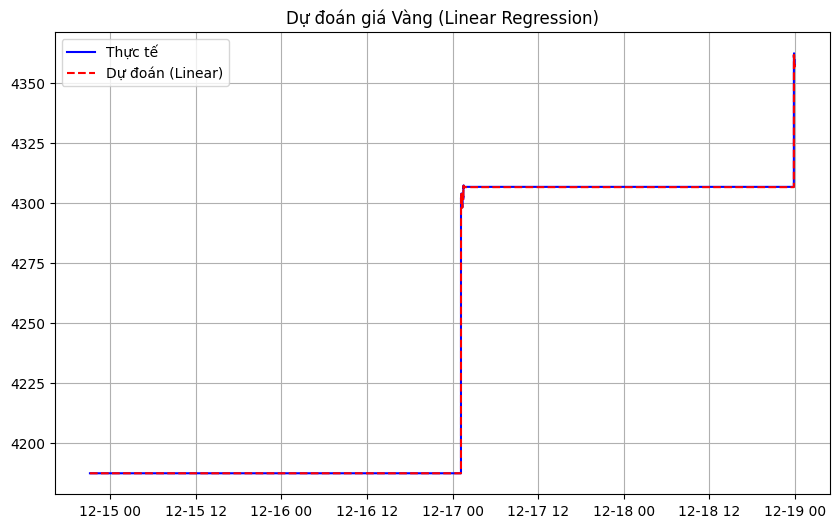

In [24]:
# 6. VẼ BIỂU ĐỒ
plt.figure(figsize=(10, 6))
plt.plot(y_test.index, actual_usd.flatten(), label='Thực tế', color='blue')
plt.plot(y_test.index, pred_usd.flatten(), label='Dự đoán (Linear)', color='red', linestyle='--')
plt.title('Dự đoán giá Vàng (Linear Regression)')
plt.legend()
plt.grid(True)
plt.show()